In [11]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt

In [12]:
DATA_PATH = Path("/home/chupchik/Рабочий стол/fisrt_stepD/The_final_recomendation/output_dataset/wazuh_features.parquet")

df = pd.read_parquet(DATA_PATH)

print(df.shape)
df.head()

(2493428, 31)


,scenario,timestamp,agent_id,agent_name,agent_ip,hostname,program,location,full_log,rule_id,...,has_401,has_403,has_500,has_sql,has_admin,has_wp,grp_attack,grp_recon,grp_scan,grp_auth
0,fox,2022-01-15 02:32:32+00:00,18,wazuh-client,172.17.131.81,mail,freshclam,/var/log/syslog,Jan 15 02:32:32 mail freshclam[29266]: Sat Jan...,52507,...,0,0,0,0,0,0,0,0,0,0
1,fox,2022-01-15 02:32:32+00:00,6,wazuh-client,192.168.128.170,taylorcruz-mail,freshclam,/var/log/syslog,Jan 15 02:32:32 taylorcruz-mail freshclam[2851...,52507,...,0,0,0,0,0,0,0,0,0,0
2,fox,2022-01-15 02:32:37+00:00,18,wazuh-client,172.17.131.81,mail,freshclam,/var/log/syslog,Jan 15 02:32:37 mail freshclam[29266]: Sat Jan...,52507,...,0,0,0,0,0,0,0,0,0,0
3,fox,2022-01-15 02:32:42+00:00,18,wazuh-client,172.17.131.81,mail,freshclam,/var/log/syslog,Jan 15 02:32:42 mail freshclam[29266]: Sat Jan...,52507,...,0,0,0,0,0,0,0,0,0,0
4,fox,2022-01-15 02:32:47+00:00,18,wazuh-client,172.17.131.81,mail,freshclam,/var/log/syslog,Jan 15 02:32:47 mail freshclam[29266]: Sat Jan...,52507,...,0,0,0,0,0,0,0,0,0,0


In [13]:
print(df.columns.tolist())

['scenario', 'timestamp', 'agent_id', 'agent_name', 'agent_ip', 'hostname', 'program', 'location', 'full_log', 'rule_id', 'rule_level', 'rule_description', 'rule_groups', 'rule_groups_str', 'y_priority', 'hour', 'dayofweek', 'is_weekend', 'is_night', 'is_internal_ip', 'has_400', 'has_401', 'has_403', 'has_500', 'has_sql', 'has_admin', 'has_wp', 'grp_attack', 'grp_recon', 'grp_scan', 'grp_auth']


In [14]:
target_col = "y_priority"

print(df[target_col].value_counts())

y_priority
medium      1873575
low          486285
high         131901
critical       1667
Name: count, dtype: int64


In [15]:
text_features = ["full_log", "rule_description"]

numeric_features = [
    "hour", "dayofweek",
    "is_weekend", "is_night",
    "is_internal_ip",
    "has_400", "has_401", "has_403", "has_500",
    "has_sql", "has_admin", "has_wp",
    "grp_attack", "grp_recon", "grp_scan", "grp_auth"
]

categorical_features = [
    "program", "location", "scenario"
]

feature_cols = text_features + numeric_features + categorical_features

# Очень важно: заранее заполняем пропуски в текстовых колонках
df["full_log"] = df["full_log"].fillna("")
df["rule_description"] = df["rule_description"].fillna("")

X = df[feature_cols].copy()
y = df[target_col].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2493428, 21)
y shape: (2493428,)


In [16]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Классы:", label_encoder.classes_)

Классы: ['critical' 'high' 'low' 'medium']


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (1994742, 21) (1994742,)
Test: (498686, 21) (498686,)


In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "tfidf_full_log",
            TfidfVectorizer(max_features=3000, ngram_range=(1, 2)),
            "full_log"
        ),
        (
            "tfidf_rule_description",
            TfidfVectorizer(max_features=500),
            "rule_description"
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ],
    remainder="drop"
)

In [19]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

In [20]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tfidf_full_log', ...), ('tfidf_rule_description', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the outp

In [21]:
y_pred = pipeline.predict(X_test)

In [22]:
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

print("\nClassification report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    digits=4
))

Macro F1: 0.999944430348602

Classification report:

              precision    recall  f1-score   support

    critical     1.0000    1.0000    1.0000       334
        high     0.9997    1.0000    0.9998     26380
         low     1.0000    1.0000    1.0000     97257
      medium     1.0000    1.0000    1.0000    374715

    accuracy                         1.0000    498686
   macro avg     0.9999    1.0000    0.9999    498686
weighted avg     1.0000    1.0000    1.0000    498686



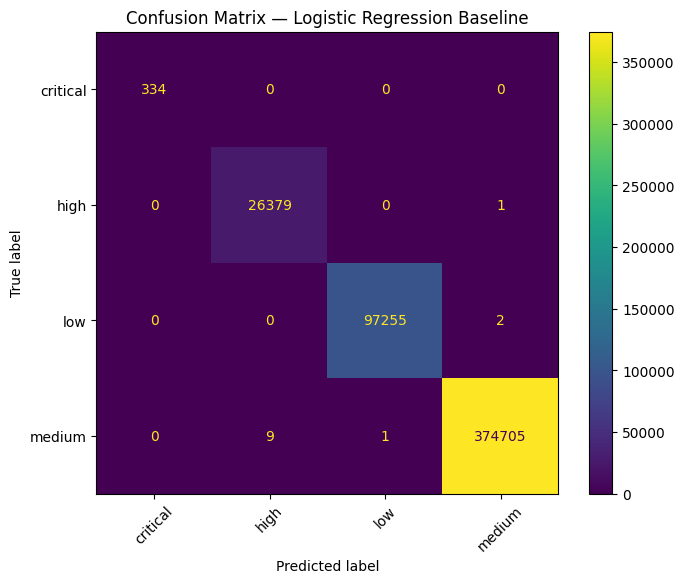

In [23]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix — Logistic Regression Baseline")
plt.show()